<a href="https://colab.research.google.com/github/w39011651/LC-PLM/blob/colabLoRA/highparameter/LoRAFineTune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git lfs --exclude=* clone https://github.com/w39011651/LC-PLM

          with new flags from 'git clone'

'git clone' has been updated in upstream Git to have comparable
speeds to 'git lfs clone'.
Cloning into 'LC-PLM'...
remote: Enumerating objects: 135, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 135 (delta 59), reused 116 (delta 50), pack-reused 0 (from 0)
Receiving objects: 100% (135/135), 4.59 MiB | 5.54 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [8]:
%cd LC-PLM
!git lfs pull

/content/LC-PLM


In [9]:
!git fetch origin
!git checkout LoRA

Already on 'LoRA'
Your branch is up to date with 'origin/LoRA'.


In [10]:
!ls
!ls -l model.safetensors
%cd ..

CODE_OF_CONDUCT.md	CONTRIBUTING.md  layer_norm.py	    model.safetensors
config.json		dataprocess	 LICENSE	    README.md
configuration_lcplm.py	highparameter	 modeling_lcplm.py
-rw-r--r-- 1 root root 3011271376 Jun 22 08:33 model.safetensors
/content


In [11]:
!pip install --no-build-isolation mamba-ssm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.4 MB/s eta 0:

In [1]:
import torch
from transformers.models.auto.tokenization_auto import AutoTokenizer
from transformers.models.auto.modeling_auto import AutoModelForMaskedLM
from transformers.utils.quantization_config import BitsAndBytesConfig
from peft import get_peft_model, LoraConfig, TaskType
import torch.nn as nn
import typing

# Dataset Preparation

## Dataset Definition

In [2]:
MAX_LEN = 128
PAD_TOKEN_ID = -100

In [3]:
from torch.utils.data import Dataset, random_split

class ATPBingindDataset(Dataset):
    def __init__(self, tokenizer, sequences, labels, max_length = 128):
        #vocab_size default is 128 in model config and tokenizer, but 512 has the lowest eval loss in reference paper
        self.tokenizer = tokenizer
        self.sequences = sequences
        self.labels = labels
        self.max_length = max_length

    def __len__(self)->int:
        return len(self.sequences)

    def __getitem__(self, index):
        try:
            sequence = self.sequences[index]
            label = self.labels[index]

            encoding = self.tokenizer(
                sequence,
                padding='max_length',
                truncation=True,
                max_length=self.max_length,
                return_tensors='pt'
            )

            padded_label = torch.full((self.max_length, ), PAD_TOKEN_ID, dtype = torch.long)
            valid_length = min(len(label), self.max_length)
            padded_label[:valid_length] = torch.tensor([int(l) for l in label[:valid_length]])

            return {
                'input_ids': encoding['input_ids'].squeeze(0),
                'attention_mask': encoding['attention_mask'].squeeze(0),
                'labels': padded_label.clone().detach()
            }

        except Exception as e:
            print(f"Error at index {index}")
            raise e

## Split dataset function

In [4]:
def split_dataset(dataset, split_size = 0.8):
    train_size = int(split_size * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    return train_dataset, test_dataset

# Data preprocess

In [5]:
import json
with open('LC-PLM/dataprocess/ATP_rmsim.json') as f:
    data = json.load(f)

def generate_label(protein, positions)->typing.List:
    n = protein['sequence']['length']
    labels = [0 for _ in range(n)]

    for bind_site in positions:
        for i in range(bind_site[0], bind_site[1]+1):
            labels[i-1] = 1#0-index或者1-index?
    return labels

def get_binding_site(features)->typing.List:
    binding_site = []
    for feature in features:
        if feature['type'] == 'Binding site' and feature['ligand']['name']=='ATP':#only need FAD
            binding_site.append([feature['location']['start']['value'], feature['location']['end']['value']])
    return binding_site

## Generate label and split sequence
until the length of each subsequence <= MAX_LEN

In [6]:
protein_information = []
ones_cnt = 0
zeros_cnt = 0
for protein in data['results']:
    info = {"sequence": [], "label": []}
    info['sequence'] = protein['sequence']['value']
    binding_site_interval = get_binding_site(protein['features'])
    info['label'] = generate_label(protein, binding_site_interval)

    if info['label'].count(0) == len(info['label']):
        continue

    ones_cnt += info['label'].count(1)
    zeros_cnt += info['label'].count(0)

    protein_information.append(info)

In [7]:
sequences = []
labels = []

for item in protein_information:
    while len(item['sequence']) > MAX_LEN:
        sequences.append(item['sequence'][:MAX_LEN])
        labels.append(item['label'][:MAX_LEN])
        item['sequence'] = item['sequence'][MAX_LEN:]
        item['label'] = item['label'][MAX_LEN:]

    sequences.append(item['sequence'])
    labels.append(item['label'])

len(sequences[-1])

86

In [8]:
import pandas as pd

df = pd.DataFrame(columns=['sample input'], data = [ones_cnt, zeros_cnt])
df

,sample input
0,6250
1,542522


# Load Model and using LoRA

In [9]:
MODEL_ID = "./LC-PLM"

quantization_config = BitsAndBytesConfig(
    load_in_8bit = True,
    # bnb_4bit_quant_type =  "nf4",
    # bnb_4bit_use_double_quant =  True,
    # bnb_4bit_compute_dtype = torch.bfloat16
)


base_model = AutoModelForMaskedLM.from_pretrained(MODEL_ID,
                          trust_remote_code = True,
                          device_map = "auto",
                          torch_dtype=torch.float32
                          )

tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
dataset = ATPBingindDataset(tokenizer, sequences, labels, max_length=MAX_LEN)


/root/.cache/huggingface/modules/transformers_modules/LC-PLM/layer_norm.py:960: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/root/.cache/huggingface/modules/transformers_modules/LC-PLM/layer_norm.py:1019: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
Some weights of LcPlmForMaskedLM were not initialized from the model checkpoint at ./LC-PLM and are newly initialized: ['bimamba.backbone.layers.0.mixer.mamba_rev.in_proj.weight', 'bimamba.backbone.layers.0.mixer.mamba_rev.out_proj.weight', 'bimamba.backbone.layers.1.mixer.mamba_rev.in_proj.weight', 'bimamba.backbone.layers.1.mixer.mamba_rev.out_proj.weight', 'bimamba.backbone.layers.10.mixer.mamba_rev.in_proj.weight', 'bimamba.backbone.layers.10.mixer.mamba_rev.out_proj.weight', 'bimamba.backbone.layers.11.mixer.mamba_rev.in_p

In [10]:
train_dataset, validate_dataset = split_dataset(dataset, 0.8)
validate_dataset, test_dataset = split_dataset(validate_dataset, 0.5)

In [11]:
print(f'{len(train_dataset)} {len(validate_dataset)} {len(test_dataset)}')

3673 459 460


In [12]:
print(base_model) ## Check the projection layer in base model

LcPlmForMaskedLM(
  (bimamba): LcPlm(
    (backbone): BiMambaMixerModel(
      (embedding): Embedding(128, 1536)
      (layers): ModuleList(
        (0-47): 48 x Block(
          (norm): RMSNorm()
          (mixer): BiMambaWrapper(
            (mamba_fwd): Mamba(
              (in_proj): Linear(in_features=1536, out_features=6144, bias=False)
              (conv1d): Conv1d(3072, 3072, kernel_size=(4,), stride=(1,), padding=(3,), groups=3072)
              (act): SiLU()
              (x_proj): Linear(in_features=3072, out_features=128, bias=False)
              (dt_proj): Linear(in_features=96, out_features=3072, bias=True)
              (out_proj): Linear(in_features=3072, out_features=1536, bias=False)
            )
            (mamba_rev): Mamba(
              (in_proj): Linear(in_features=1536, out_features=6144, bias=False)
              (conv1d): Conv1d(3072, 3072, kernel_size=(4,), stride=(1,), padding=(3,), groups=3072)
              (act): SiLU()
              (x_proj): Linear(

In [13]:
lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=[
        "mixer.mamba_fwd.in_proj",
        "mixer.mamba_fwd.x_proj",
        "mixer.mamba_fwd.dt_proj",
        "mixer.mamba_fwd.out_proj",
        "mixer.mamba_rev.in_proj",
        "mixer.mamba_rev.x_proj",
        "mixer.mamba_rev.dt_proj",
        "mixer.mamba_rev.out_proj"
    ],
    bias="none"
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
print("Loading model complete")
print(f"Device Type:{type(model)}")
print(f"Device:{next(model.parameters()).device}")

trainable params: 28,655,616 || all params: 1,460,725,248 || trainable%: 1.9617
Loading model complete
Device Type:<class 'peft.peft_model.PeftModelForFeatureExtraction'>
Device:cuda:0


## Define Sequence Labeling Class

In [14]:
class LCPLMLoRAForSequenceLabeling(nn.Module):
    def __init__(self, base_model, num_labels=2):
        super().__init__()
        self.base_model = base_model
        self.classifier = nn.Linear(base_model.config.d_model, num_labels)#後續可以替換成簡單的CNN分類
        self.drop_out = nn.Dropout(0.1)
        self.loss_fn = nn.CrossEntropyLoss()

    def forward(self, input_ids, attention_mask = None, labels = None):
        outputs = self.base_model(
            input_ids = input_ids,
            attention_mask = attention_mask,
            output_hidden_states = True
        )
        # Get the output from basemodel
        # This part is with gradient or no gradient? It should be no gradient because the limit of GPU's memory
        sequence_output = outputs.hidden_states[-1]
        logits = self.classifier(sequence_output)
        loss = None
        if labels is not None:# 後續可使用Mask遮罩來加強訓練
            active_logits = logits.view(-1, logits.size(-1))
            active_labels = labels.view(-1)
            loss = self.loss_fn(active_logits, active_labels)

        return loss, logits

In [15]:
sequence_model = LCPLMLoRAForSequenceLabeling(base_model, num_labels=2)

## Custom Evaluation function and find the best threshold

In [16]:
import numpy as np
from sklearn.metrics import classification_report, roc_curve, matthews_corrcoef
from sklearn.metrics import roc_curve

def find_best_evalution(logits, labels, mode = 'gmean'):
    logits_np = np.array(logits)
    labels_np = np.array(labels)
    probs = 1 / (1+ np.exp(-logits_np[:,:,1]))

    labels_flat = labels_np.flatten()
    probs_flat = probs.flatten()

    active_indices = labels_flat != -100 # ignore mask
    final_labels = labels_flat[active_indices]
    final_probs = probs_flat[active_indices]

    fpr, tpr, thresholds = roc_curve(final_labels, final_probs)
    if mode == 'gmean':
        gmeans = np.sqrt(tpr * (1-fpr))
        ix = np.argmax(gmeans)
        best_threshold = thresholds[ix]
        return best_threshold
    elif mode == 'mcc':
        mcc_score_at_each_threshold = []

        for threshold in thresholds:
            predicted_classes_at_threshold = (final_probs > threshold).astype(int)
            mcc = matthews_corrcoef(final_labels, predicted_classes_at_threshold)
            mcc_score_at_each_threshold.append(mcc)

        max_mcc_score_index = np.argmax(mcc_score_at_each_threshold)
        best_threshold = thresholds[max_mcc_score_index]
        best_mcc = mcc_score_at_each_threshold[max_mcc_score_index]

        return best_threshold
    else:
        return 0.5

In [39]:
def custom_classification_report(logits, labels, mode):
    labels_np = np.array(labels)
    logits_np = np.array(logits)

    threshold = find_best_evalution(logits, labels, mode)
    print(f"The best threshold is: {threshold}")
    probs = 1/(1+np.exp(-logits_np[:,:,1]))
    preds = (probs > threshold).astype(int).flatten()
    labels_flat = labels_np.flatten()


    active_indices = labels_flat != -100
    final_labels = labels_flat[active_indices]
    final_preds = preds[active_indices]
    report_str = classification_report(final_labels, final_preds)
    report_dict = classification_report(final_labels, final_preds, output_dict=True)
    print(report_str)
    return report_dict

In [18]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0
    total_samples = 0

    with torch.no_grad():
        for batch in dataloader:
            inputs = {k:v.to(device) for k, v in batch.items() if k != "labels"}
            labels = batch['labels'].to(device)

            loss, _ = model(**inputs, labels=labels)
            total_loss += loss.item() * labels.size(0)
            total_samples += labels.size(0)

    return total_loss / total_samples

In [19]:
from transformers.training_args import TrainingArguments
from transformers.trainer import Trainer
from torch.utils.data import DataLoader
from tqdm import tqdm
import torch.optim as optim
from transformers.optimization import get_linear_schedule_with_warmup

def train(model):
    # Training Arguments 訓練參數
    output_dir="./results"
    num_train_epochs=3
    per_device_train_batch_size=4
    per_device_eval_batch_size=8
    weight_decay=0.01
    logging_dir="./logs"
    logging_steps=80
    eval_steps=500
    save_steps=1000
    eval_strategy="steps"
    save_strategy="steps"
    load_best_model_at_end=True
    metric_for_best_model="eval_loss"
    greater_is_better=False
    learning_rate=5e-4
    warmup_steps=100
    gradient_accumulation_steps=2
    fp16=True  # 使用混合精度訓練, Mamba seems like doesn't support mix precision,using fp32 will exceed limitation of VRAM
    remove_unused_columns=False  # 重要：保留自訂欄位
    dataloader_pin_memory=False
    report_to=None  # 關閉 wandb 等報告

    # Device setting 設備設定
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    # Create DataLoader 創建 DataLoader
    train_loader = DataLoader(train_dataset, per_device_train_batch_size, shuffle=True)
    validate_loader = DataLoader(validate_dataset, per_device_eval_batch_size, shuffle=True)
    total_steps = len(train_loader) * num_train_epochs

    # Calculate total steps
    total_steps = len(train_loader) * num_train_epochs

    # Setting Optimizer and Scheduler
    optimizer = optim.AdamW(
        model.parameters(),
        lr = learning_rate,
        weight_decay = weight_decay
    )
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Early Stopping parameter
    patience = 10
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state_dict = None
    global_steps = 0

    print(f"Starting Training...")
    print(f"Total Training steps: {total_steps}")
    print(f"Each Epoch steps: {len(train_loader)}")

    for epoch in range(num_train_epochs):
        sequence_model.train()
        total_train_loss = 0

        for steps, batch in enumerate(tqdm(train_loader, desc = f"Epoch {epoch+1}")):
            ##########################Training Part Below##########################
            inputs = {k:v.to(device) for k, v in batch.items() if k != "labels"}
            labels = batch['labels'].to(device)

            loss, _ = sequence_model(**inputs, labels=labels)
            loss = loss / gradient_accumulation_steps
            loss.backward()
            total_train_loss += loss.item()
            global_steps += 1

            if global_steps % logging_steps == 0:
                avg_train_loss = total_train_loss / (steps + 1)
                current_lr = scheduler.get_last_lr()[0]
                print(f"Epoch {epoch+1}, Step {steps + 1}, "
                      f"Training Loss: {avg_train_loss:.6f}, "
                      f"LR: {current_lr:.2e}")

            if (steps + 1) % gradient_accumulation_steps == 0:
                nn.utils.clip_grad_norm_(sequence_model.parameters(), max_norm=1.0)# 梯度裁減
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()
            ##########################Training Part Above##########################
            ##########################Validate Part Below##########################
            if (global_steps % eval_steps == 0):
                val_loss = evaluate(sequence_model, validate_loader, device)
                print(f"Validate loss: {val_loss:.6f}")

                # Early Stopping Checking
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    epochs_no_improve = 0
                    best_model_state_dict = sequence_model.state_dict().copy()
                    torch.save(best_model_state_dict, "atp_binding_model_lora_mamba.pt")
                else:
                    epochs_no_improve += 1

                if epochs_no_improve >= patience:
                    print("No improvement found during training.")
                    break
                sequence_model.train()
            ##########################Validate Part Above##########################
    if best_model_state_dict is not None:
        sequence_model.load_state_dict(best_model_state_dict)
        print(f'Loading best model, eval loss is: {best_val_loss}')

    return sequence_model




In [20]:
trained_model = train(sequence_model)

Starting Training...
Total Training steps: 2757
Each Epoch steps: 919


Epoch 1:   9%|▊         | 80/919 [01:38<14:43,  1.05s/it]

Epoch 1, Step 80, Training Loss: 0.346887, LR: 1.95e-04


Epoch 1:  17%|█▋        | 160/919 [03:02<13:18,  1.05s/it]

Epoch 1, Step 160, Training Loss: 0.191226, LR: 3.95e-04


...

Epoch 3, Step 802, Training Loss: 0.007253, LR: 2.71e-04


Epoch 3:  96%|█████████▌| 882/919 [18:20<00:38,  1.05s/it]

Epoch 3, Step 882, Training Loss: 0.007345, LR: 2.63e-04


Epoch 3: 100%|██████████| 919/919 [18:58<00:00,  1.24s/it]

Loading best model, eval loss is: 0.022237398884358585


## Evaluate

In [22]:
def test(model, test_loader, device):
  per_device_eval_batch_size = 8
  model.eval()
  all_test_logits = []
  all_test_labels = []
  with torch.no_grad():
    for batch in test_loader:
      inputs = {k:v.to(device) for k, v in batch.items() if k != "labels"}
      labels = batch['labels'].to(device)

      loss, logits = model(**inputs, labels=labels)
      all_test_logits.extend(logits.cpu().numpy())
      all_test_labels.extend(labels.cpu().numpy())

  return all_test_logits, all_test_labels

In [40]:
per_device_eval_batch_size = 8
device = "cuda" if torch.cuda.is_available() else "cpu"
validate_loader = DataLoader(validate_dataset, per_device_eval_batch_size, shuffle=True) # Test validate loss
test_loader = DataLoader(test_dataset, per_device_eval_batch_size, shuffle=False)
validate_loss = evaluate(trained_model, validate_loader, device)
print(f"Validate loss: {validate_loss:.6f}")


Validate loss: 0.022910


In [41]:
test_logits, test_labels = test(trained_model, test_loader, device)
custom_classification_report(test_logits, test_labels, 'mcc')

The best threshold is: 0.5205866694450378
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     55500
           1       0.95      0.87      0.91       619

    accuracy                           1.00     56119
   macro avg       0.98      0.93      0.95     56119
weighted avg       1.00      1.00      1.00     56119



{'0': {'precision': 0.9985240118079055,
  'recall': 0.9995315315315315,
  'f1-score': 0.9990275176487537,
  'support': 55500.0},
 '1': {'precision': 0.9538188277087034,
  'recall': 0.8675282714054927,
  'f1-score': 0.9086294416243654,
  'support': 619.0},
 'accuracy': 0.9980755180954757,
 'macro avg': {'precision': 0.9761714197583045,
  'recall': 0.9335299014685121,
  'f1-score': 0.9538284796365596,
  'support': 56119.0},
 'weighted avg': {'precision': 0.9980309077084488,
  'recall': 0.9980755180954757,
  'f1-score': 0.9980304149017502,
  'support': 56119.0}}

## Draw the figure: ROC-AUC curve, PRC curve and Confusion matrix heatmap

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

def roc_auc_curve(logits, labels):
  logits_np = np.array(logits)
  labels_np = np.array(labels)
  pobs = 1 / (1 + np.exp(-logits_np[:,:,1]))
  labels_flat = labels_np.flatten()
  probs_flat = pobs.flatten()

  active_indices = labels_flat != -100
  final_labels = labels_flat[active_indices]
  final_probs = probs_flat[active_indices]

  fpr, tpr, thresholds = roc_curve(final_labels, final_probs)
  roc_auc = auc(fpr, tpr)
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.legend(loc="lower right")
  plt.show()


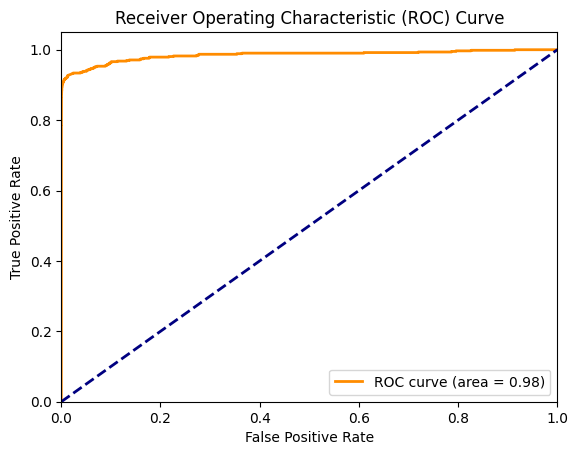

In [43]:
roc_auc_curve(test_logits, test_labels)

In [44]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

def prc_curve(logits, labels):
  logits_np = np.array(logits)
  labels_np = np.array(labels)
  pobs = 1 / (1 + np.exp(-logits_np[:,:,1]))
  labels_flat = labels_np.flatten()
  probs_flat = pobs.flatten()

  active_indices = labels_flat != -100
  final_labels = labels_flat[active_indices]
  final_probs = probs_flat[active_indices]

  # Calculate precision and recall
  precision, recall, thresholds = precision_recall_curve(final_labels, final_probs)

  # Option 1: Using PrecisionRecallDisplay
  display = PrecisionRecallDisplay(precision=precision, recall=recall)
  display.plot()
  plt.title("Precision-Recall Curve")
  plt.show()


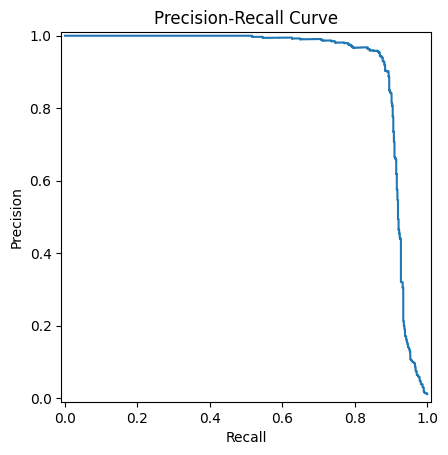

In [45]:
prc_curve(test_logits, test_labels)

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
def my_confusion_matrix(logits, labels):
  logits_np = np.array(logits)
  labels_np = np.array(labels)

  logits_flat = logits_np.reshape(-1, logits_np.shape[-1])
  labels_flat = labels_np.flatten()

  threshold =  0.5205866694450378
  preds_flat = (logits_flat[:, 1] > threshold).astype(int)

  active_indices = labels_flat != PAD_TOKEN_ID
  final_labels = labels_flat[active_indices]
  final_preds = preds_flat[active_indices]

  cm = confusion_matrix(final_labels, final_preds)

  print("Comfusion matrix\n\n", cm)
  print("\nTrue Positives(TP)", cm[0,0])
  print("\nTrue Negatives(TN)", cm[1,1])
  print("\nFalse Positives(FP)", cm[0,1])
  print("\nFalse Negatives(FN)", cm[1,0])

  plt.figure(figsize=(6,4))
  sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
  plt.ylabel('Actual label');
  plt.xlabel('Predicted label');
  plt.title('Confusion Matrix Heatmap');
  plt.show()

Comfusion matrix

 [[55481    19]
 [  101   518]]

True Positives(TP) 55481

True Negatives(TN) 518

False Positives(FP) 19

False Negatives(FN) 101


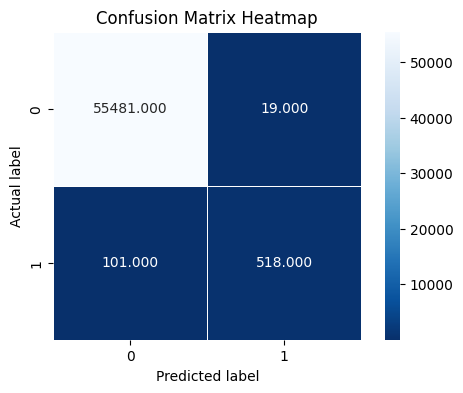

In [68]:
my_confusion_matrix(test_logits, test_labels)